$$\frac{\partial T}{\partial t} - \nu \frac{\partial ^2 T}{\partial x^2} - \nu \frac{\partial ^2 T}{\partial y^2} = 0$$



---




* $T(0,y,t) = 0$
* $T(1,y,t) = 1$
* $\dfrac{\partial T}{\partial y} = 0,$ para $y=0$ e $y=1$
* $T(x,y,0) = x$
* Analítica: $T(x,y,t) = 0$



---



# Bibliotecas

In [4]:
#------------------- Bibliotecas utilizadas --------------------------
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from IPython.display import display, Math, Latex

import time
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

from devito import Grid, Function, TimeFunction, Operator, configuration, Eq, solve, Constant
from sympy import nsimplify, pprint
from devito.logger import warning
from examples.cfd import plot_field, init_hat

# Problema

In [5]:
nx = 11
ny = nx

nu = 1

dx = 1. / (nx - 1)
dy = 1. / (ny - 1)
sigma = .22
dt = sigma * dx * dy / nu

tstop = 2.0
nt = round(tstop / dt)

In [6]:
x0         = 0
x1         = 1
compx      = x1-x0
y0         = 0
y1         = 1
compy      = y1-y0

In [7]:
origin = (x0,y0)
extent = (compx,compy)
shape  = (nx,ny)
grid   = Grid(origin=origin,extent=extent,shape=shape)

In [8]:
(x, y)  = grid.dimensions
time    = grid.time_dim
t       = grid.stepping_dim
X,Y = np.meshgrid(np.linspace(x0, x1, nx), np.linspace(y0, y1, ny), indexing='ij')

## $f = 0$

In [9]:
u = TimeFunction(name='u', grid=grid, space_order=2)  # T
right = 0

eq = Eq(u.dt - nu * (u.laplace), right)
stencil = solve(eq, u.forward)
eq_stencil = Eq(u.forward, stencil)

eq_stencil

Eq(u(t + dt, x, y), dt*(Derivative(u(t, x, y), (x, 2)) + Derivative(u(t, x, y), (y, 2)) + u(t, x, y)/dt))

In [10]:
# Initial Condiotion
u.data[0] = 0

# Boundary Conditions
bc = [Eq(u[t+1,0, y], 0.)]  # p = 0 @ x = 0
bc += [Eq(u[t+1,nx-1, y], 1)]  # p = y @ x = 1

bc += [Eq(u[t+1,x, 0], u[t+1,x, 1])]  # dp/dy = 0 @ y = 0
bc += [Eq(u[t+1,x, ny-1], u[t+1,x, ny-2])]  # dp/dy = 0 @ y = 1

op = Operator([eq_stencil] + bc)

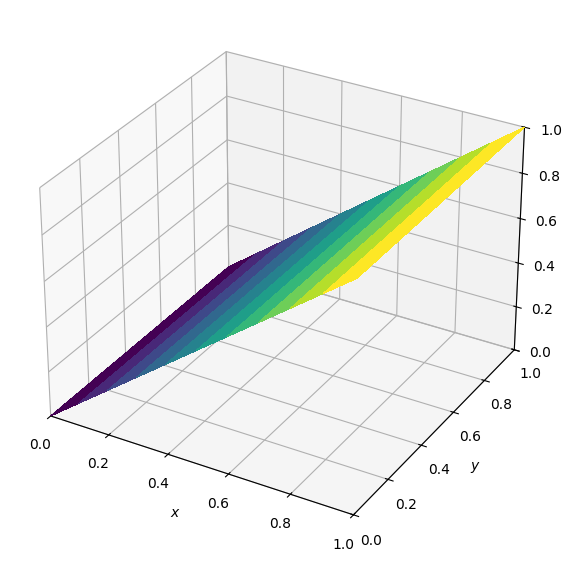

In [11]:
configuration['log-level'] = 'ERROR'

op(time=nt,dt = dt)

plot_field(u.data[0], xmin=x0, xmax=x1, ymin=y0, ymax=y1)

In [12]:
x_analytical = np.linspace(x0, x1, nx)
y_analytical = np.linspace(y0, y1, ny)
T_analytical = X

In [13]:
relative_error = np.linalg.norm(T_analytical - u.data[0]) / np.sqrt(nx*ny)
relative_error

np.float64(2.933815719281541e-07)

## $f = 2\nu$

In [18]:
u = TimeFunction(name='u', grid=grid, space_order=2)
right = 2*nu

eq = Eq(u.dt - nu * (u.laplace), right)
stencil = solve(eq, u.forward)
eq_stencil = Eq(u.forward, stencil)

eq_stencil

Eq(u(t + dt, x, y), dt*(Derivative(u(t, x, y), (x, 2)) + Derivative(u(t, x, y), (y, 2)) + 2 + u(t, x, y)/dt))

In [19]:
# Initial Condiotion
u.data[0] = 0

# Boundary Conditions
bc = [Eq(u[t+1,0, y], 0.)]  # u = 0 @ x = 0
bc += [Eq(u[t+1,nx-1, y], 0)]  # u = y @ x = 1

bc += [Eq(u[t+1,x, 0], u[t+1,x, 1])]  # du/dy = 0 @ y = 0
bc += [Eq(u[t+1,x, ny-1], u[t+1,x, ny-2])]  # du/dy = 0 @ y = 1

op = Operator([eq_stencil] + bc)

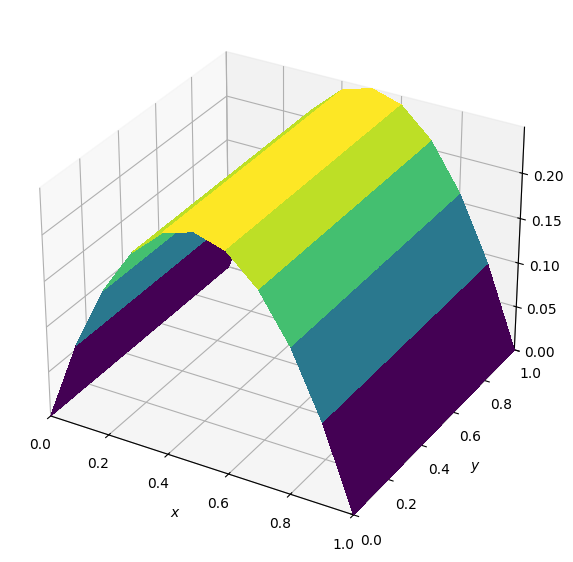

In [20]:
configuration['log-level'] = 'ERROR'

op(time=nt,dt = dt)

plot_field(u.data[0], xmin=x0, xmax=x1, ymin=y0, ymax=y1)

# Completo

In [21]:
def plot_3d_comparison(x, y, numerical_solution, analytical_solution):
    """
    Plota comparação 3D entre solução numérica (superfície) e analítica (pontos)

    Parâmetros:
    x : array 1D - coordenadas x da malha
    y : array 1D - coordenadas y da malha
    numerical_solution : array 2D - solução numérica em toda a malha
    analytical_solution : array 2D - solução analítica em toda a malha
    """
    # Cria malha para plotagem 3D
    X, Y = np.meshgrid(x, y, indexing='ij')

    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plota superfície da solução numérica
    surf = ax.plot_surface(X, Y, numerical_solution.T,
                          cmap='viridis', alpha=0.7,
                          label='Solução Numérica')

    # Plota pontos da solução analítica (mostrando 1 a cada 2 pontos para melhor visualização)
    scatter = ax.scatter(X[::2,::2], Y[::2,::2], analytical_solution.T[::2,::2],
                        color='red', s=50, depthshade=True,
                        label='Solução Analítica')

    # Configurações do gráfico
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_zlabel('T(t,x,y)', fontsize=12)
    #ax.set_title('Comparação 3D: Solução Numérica vs Analítica', fontsize=14)

    # Criando legendas
    surf._edgecolors2d = surf._edgecolor3d
    surf._facecolors2d = surf._facecolor3d
    ax.legend()

    # Ajusta a visualização
    ax.view_init(elev=30, azim=45)
    plt.tight_layout()
    plt.show()

def run_simulation(nx_values=[11, 21, 41]):
    convergence_results = []
    all_results = {}

    for nx in nx_values:
        print(f"\nExecutando simulação para nx = {nx}\n")
        ny = nx
        nu = 1

        x0 = 0
        x1 = 1
        compx = x1 - x0
        y0 = 0
        y1 = 1
        compy = y1 - y0
        dx = compx / (nx - 1)
        dy = compy / (ny - 1)
        sigma = 0.25
        dt = (sigma * dx * dy) / nu

        tstop = 1
        nt = round(tstop / dt)

        origin = (x0, y0)
        extent = (compx, compy)
        shape = (nx, ny)
        grid = Grid(origin=origin, extent=extent, shape=shape)
        (x, y) = grid.dimensions
        time = grid.time_dim
        t = grid.stepping_dim
        X,Y = np.meshgrid(np.linspace(x0, x1, nx), np.linspace(y0, y1, ny), indexing='ij')

        f = 0

        u = TimeFunction(name='u', grid=grid, space_order=2, time_order=1)
        eq = Eq(u.dt - nu * (u.dx2 + u.dy2), f)
        stencil = solve(eq, u.forward)
        eq_stencil = Eq(u.forward, stencil)

        u.data[0] = X  #X*(1-X)

        # Condições de Contorno
        bc = [Eq(u[t+1, 0, y], 0.)]
        bc += [Eq(u[t+1, nx-1, y], 1)]
        bc += [Eq(u[t+1,x, 0], u[t+1,x, 1])]  # dp/dy = 0 @ y = 0
        bc += [Eq(u[t+1,x, ny-1], u[t+1,x, ny-2])]  # dp/dy = 0 @ y = 1

        op = Operator([eq_stencil] + bc)
        configuration['log-level'] = 'ERROR'
        %time op(time=nt, dt=dt)

        # Plotagem da solução final
        # 3D
        plot_field(u.data[0], xmin=x0, xmax=x1, ymin=y0, ymax=y1)

        # Solução Analítica
        x_analytical = np.linspace(x0, x1, nx)
        y_analytical = np.linspace(y0, y1, ny)
        T_analytical = X

        # Plot da comparação
          # em um corte
        plt.figure(figsize=(10, 6))
        plt.plot(x_analytical, T_analytical[:,ny//2], label='Solução Analítica', marker='o')
        plt.plot(x_analytical, u.data[0, :, ny//2], label='Solução Numérica', marker='x')
        plt.xlabel('x')
        plt.ylabel('T(t,x,y)')
        plt.legend()
        plt.grid(True)
        plt.show()

        # 2D
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.contourf(X, Y, u.data[0], levels=50, cmap='viridis')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        plt.colorbar(ax.contourf(X, Y, u.data[0], levels=50, cmap='viridis'), label='T(t,x,y)')
        plt.show()

        # Erro Relativo
        relative_error = np.sqrt(np.sum((T_analytical - u.data)**2 )) / np.sqrt(np.sum((T_analytical)**2 ))

        # Armazanemanto dos resultados para análise da convergência
        all_results[nx] = {
            'x': X,
            'numerical': u.data[0],
            'analytical': T_analytical,
            'rel_error': relative_error,
            'h': dx,
            'dt': dt
        }
    plt.show()

    # Cálculo das ordens de convergência
    nx_sorted = sorted(all_results.keys())
    for i, nx in enumerate(nx_sorted):
        if i == 0:
            q_h = np.nan
            q_dt = np.nan
        else:
            prev_nx = nx_sorted[i-1]
            atual_nx = nx_sorted[i]
            E1 = all_results[prev_nx]['rel_error']
            E2 = all_results[atual_nx]['rel_error']
            h1 = all_results[prev_nx]['h']
            h2 = all_results[atual_nx]['h']
            dt1 = all_results[prev_nx]['dt']
            dt2 = all_results[atual_nx]['dt']

            q_h = np.log(E1/E2) / np.log(h1/h2)
            q_dt = np.log(E1/E2) / np.log(dt1/dt2)

        convergence_results.append({
            'N': nx,
            'h': all_results[nx]['h'],
            'dt_visc': all_results[nx]['dt'],
            'Erro': all_results[nx]['rel_error'],
            'q_h': q_h,
            'q_dt_visc': q_dt
        })

    # Tabela da convergência
    df_convergence = pd.DataFrame(convergence_results)
    print("\nConvergence Analysis Table:")
    print(df_convergence.to_string(float_format="%.4e"))

    return all_results, df_convergence


Executando simulação para nx = 11

CPU times: user 51 ms, sys: 2.98 ms, total: 54 ms
Wall time: 54.2 ms


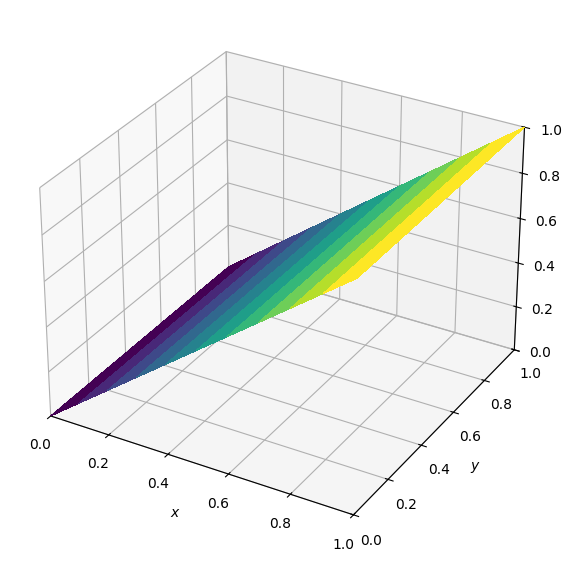

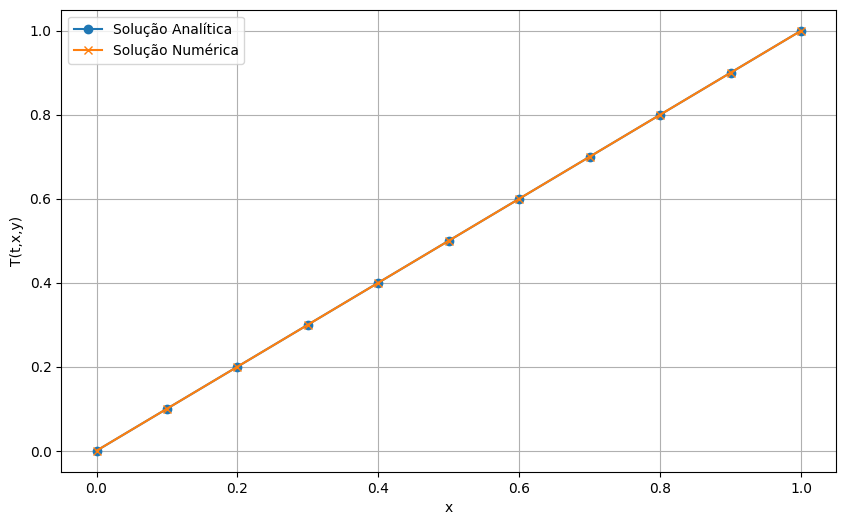

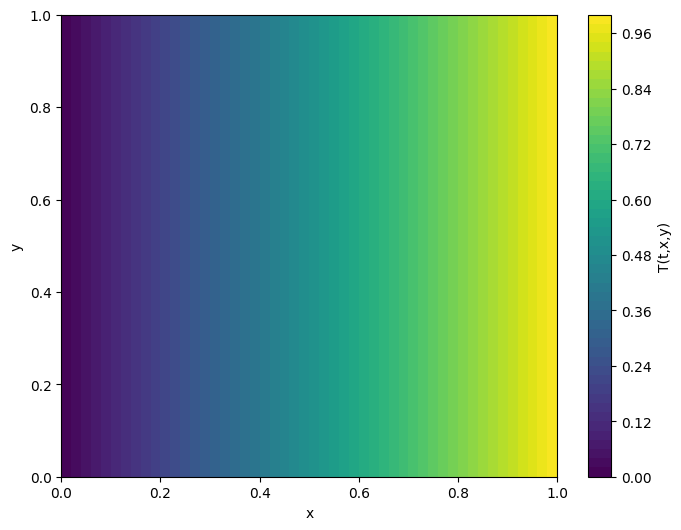


Executando simulação para nx = 21

CPU times: user 45.6 ms, sys: 2.86 ms, total: 48.5 ms
Wall time: 239 ms


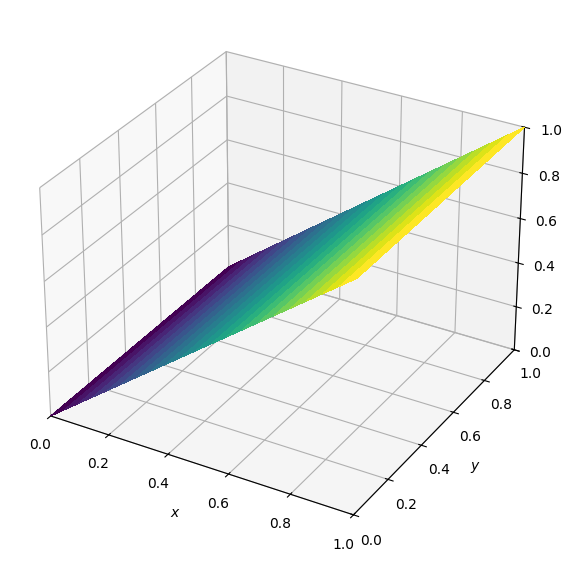

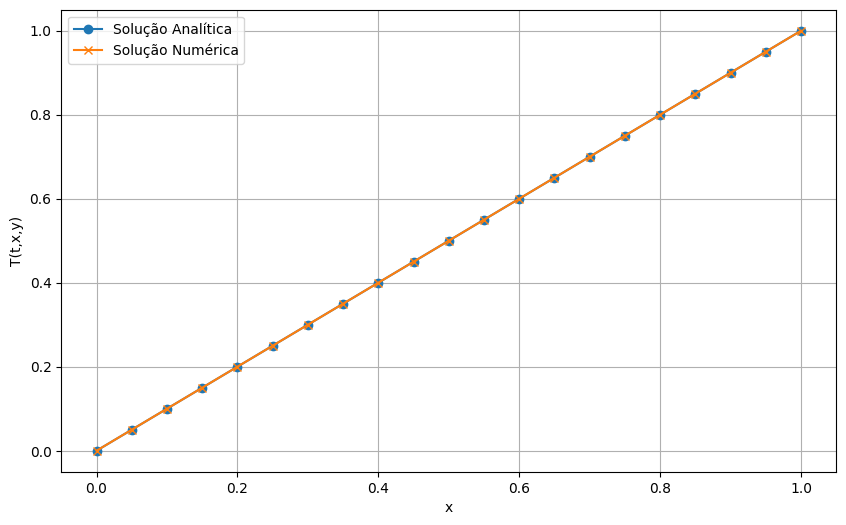

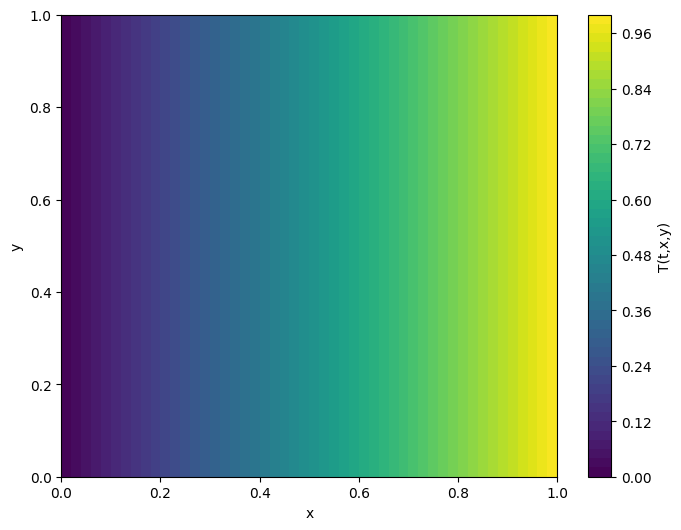


Executando simulação para nx = 41

CPU times: user 52 ms, sys: 3.92 ms, total: 55.9 ms
Wall time: 259 ms


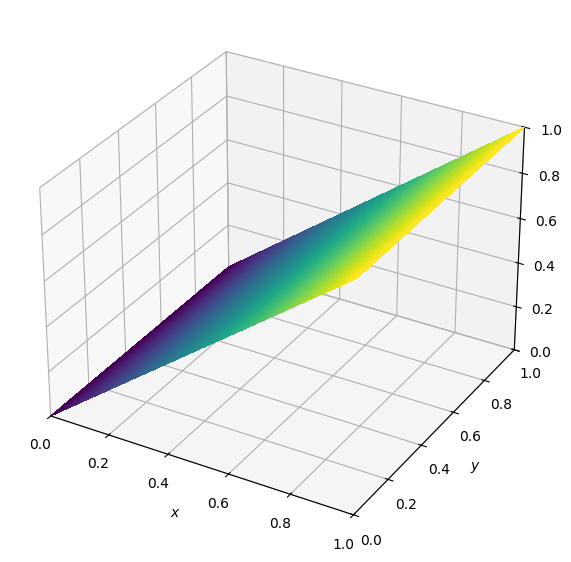

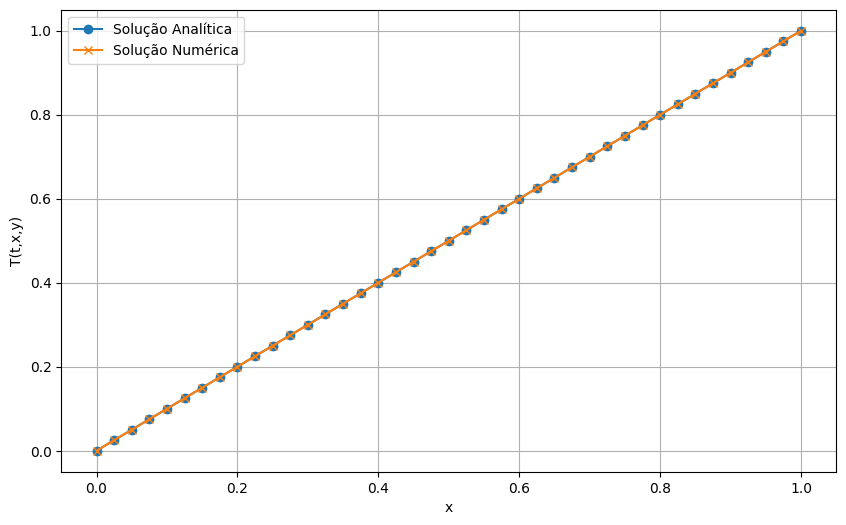

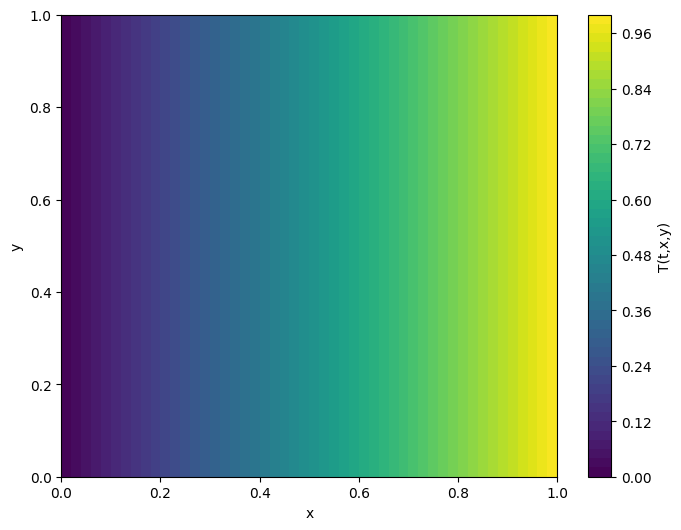


Executando simulação para nx = 81

CPU times: user 128 ms, sys: 3 ms, total: 131 ms
Wall time: 319 ms


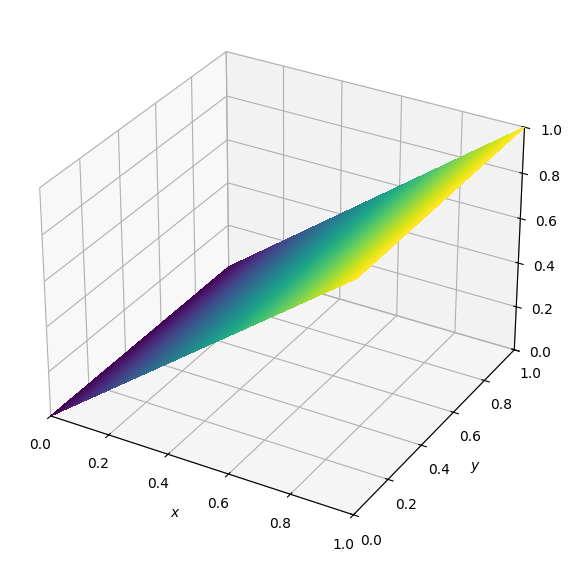

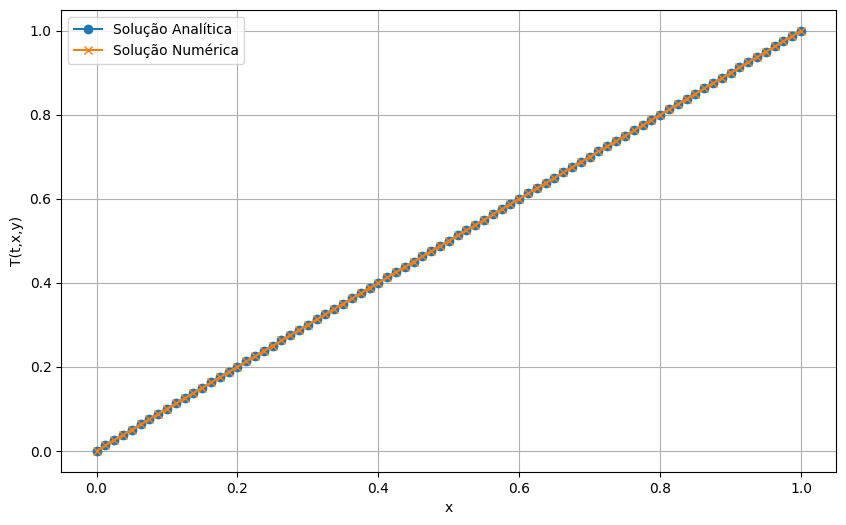

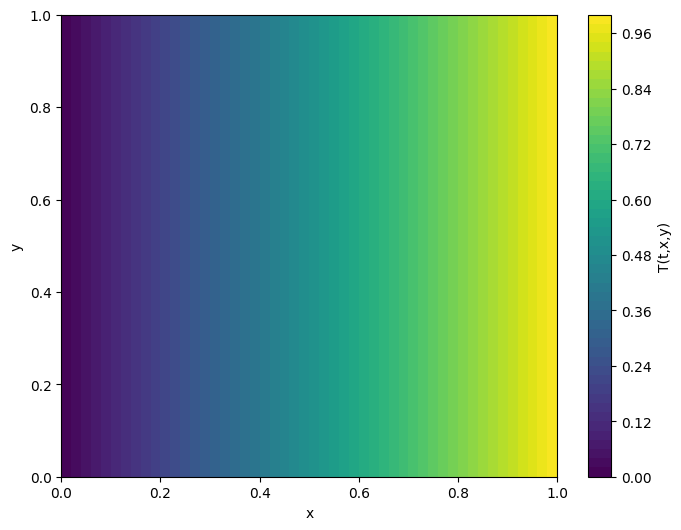


Convergence Analysis Table:
    N          h    dt_visc                    Erro                  q_h             q_dt_visc
0  11 1.0000e-01 2.5000e-03   8.620033974964748e-08                  NaN                   NaN
1  21 5.0000e-02 6.2500e-04  5.2422248353380575e-08   0.7175143243881813   0.35875716219409065
2  41 2.5000e-02 1.5625e-04    7.34060139602212e-08  -0.4857190329231075  -0.24285951646155374
3  81 1.2500e-02 3.9063e-05   9.036507855992014e-08  -0.2998670890568327  -0.14993354452841634


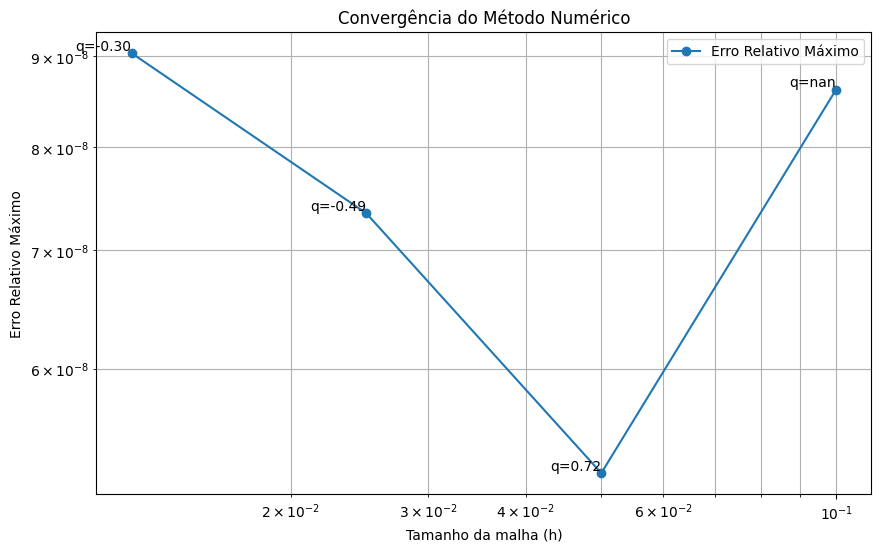

In [22]:
# Simulações
all_results, df_convergence = run_simulation(nx_values=[11, 21, 41, 81])

# Mis plots
plt.figure(figsize=(10, 6))
plt.loglog(df_convergence['h'], df_convergence['Erro'], 'o-', label='Erro Relativo Máximo')
for i, row in df_convergence.iterrows():
    plt.text(row['h'], row['Erro'], f"q={row['q_h']:.2f}", ha='right', va='bottom')
plt.xlabel('Tamanho da malha (h)')
plt.ylabel('Erro Relativo Máximo')
plt.title('Convergência do Método Numérico')
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()